In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

from graphufs.stacked_utils import convert_loss_channel2var, get_channel_index
from graphufs.datasets import Dataset

In [2]:
# local variables
_scratch = "/pscratch/sd/n/nagarwal/"
_prototype = "ocn-only"
_expt = "R4"
_prototype_dir_home = "/global/homes/n/nagarwal/graph-ufs/prototypes/"
_inference_dir = os.path.join(_scratch, _prototype, _expt,
                              "inference", "validation")

In [3]:
# get the metadata
from prototypes.ocn_only.R4.config import OcnTrainer as Emulator 
em = Emulator()
tds = Dataset(em, mode="training")
xinputs, xtargets, _ = tds.get_xarrays(0)
sinputs, stargets = tds[0]

tmeta_inp = get_channel_index(xinputs)
tmeta_inp

/global/homes/n/nagarwal/graph-ufs/graphufs/fvcoupledemulator.py:25: UserWarning: Could not import flox, install with 'conda install -c conda-forge flox' for faster volume averaging (i.e. groupby operations)
  warnings.warn("Could not import flox, install with 'conda install -c conda-forge flox' for faster volume averaging (i.e. groupby operations)")


TypeError: Dataset._add_gaussian_noise() missing 1 required positional argument: 'fraction'

In [ ]:
tmeta_tar = get_channel_index(xtargets)
tmeta_tar

## Inputs

In [ ]:
# open inputs from the training data
ds_dir =  os.path.join(_scratch, _prototype, _expt, "training")
ds = xr.open_zarr(f'{ds_dir}/inputs.zarr/')
ds

In [6]:
ds_dir =  os.path.join(_scratch, _prototype, _expt, "stacked-normalization", "inputs")
ds_mean = xr.open_zarr(os.path.join(ds_dir, "mean_by_level.zarr"))
ds_std = xr.open_zarr(os.path.join(ds_dir, "stddev_by_level.zarr"))

In [7]:
ds_normalized = (ds - ds_mean)/ds_std

## Targets

In [8]:
# open targets from the training data
ds_dir =  os.path.join(_scratch, _prototype, _expt, "training")
ds = xr.open_zarr(f'{ds_dir}/targets.zarr/')
ds

<xarray.Dataset> Size: 919GB
Dimensions:   (channels: 41, lat: 192, lon: 384, sample: 37983)
Coordinates:
  * channels  (channels) int64 328B 0 1 2 3 4 5 6 7 ... 33 34 35 36 37 38 39 40
  * lat       (lat) float64 2kB 89.82 88.89 87.95 87.01 ... -87.25 -88.18 -89.12
  * lon       (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * sample    (sample) int64 304kB 0 1 2 3 4 5 ... 37978 37979 37980 37981 37982
Data variables:
    targets   (sample, lat, lon, channels) float64 919GB dask.array<chunksize=(1, 192, 384, 32), meta=np.ndarray>

In [18]:
ds.targets.dims

('sample', 'lat', 'lon', 'channels')

In [9]:
ds_dir =  os.path.join(_scratch, _prototype, _expt, "stacked-normalization", "targets")
ds_mean = xr.open_zarr(os.path.join(ds_dir, "mean_by_level.zarr"))
ds_std = xr.open_zarr(os.path.join(ds_dir, "stddev_by_level.zarr"))
ds_stddiff = xr.open_zarr(os.path.join(ds_dir, "diffs_stddev_by_level.zarr"))

In [10]:
ds_normalized = (ds - ds_mean)/ds_std

## Cross-Channel Correlation

In [30]:
def cross_correlation_matrix(da: xr.DataArray, var_dim: str = "channels"):
  """
  Calculates the correlation matrix for all pairs along dim.

  Args:
    da (xr.Dataset): The input DataArray.
    var_dim (str): The shared dimension along which variables are defined.

  Returns:
    xr.Dataset: A Dataset containing the correlation matrix.
  """

  channels = ds[var_dim]  # Get the dim values
    
  corr_mat = np.zeros((len(channels), len(channels)))
  for i in range(len(channels)):
    for j in range(i, len(channels)):
      print(f"i={i}, j={j}")
      channel_i = channels[i]
      channel_j = channels[j]

      # Calculate correlation
      corr_mat[i, j] = xr.corr(da.isel({var_dim:channel_i}), da.isel({var_dim:channel_j})).compute() 

  return corr_mat

In [ ]:
cross_corr = cross_correlation_matrix(ds.targets.isel(sample=slice(None, 100)), var_dim=("channels"))

In [46]:
len(ds.targets["channels"])

41

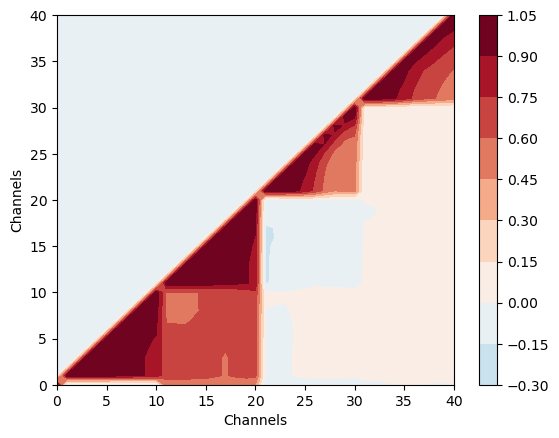

In [51]:
plt.contourf(cross_corr, vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar()
plt.xlabel("Channels")
plt.ylabel("Channels")
plt.show()

In [40]:
cross_corr

array([[ 1.        , -0.15487502, -0.15494412, ..., -0.00306497,
        -0.00246706, -0.00260338],
       [ 0.        ,  1.        ,  0.9999992 , ...,  0.0074226 ,
         0.00799302,  0.0075207 ],
       [ 0.        ,  0.        ,  1.        , ...,  0.00742753,
         0.0079965 ,  0.00752322],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
         0.93719796,  0.86529823],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         1.        ,  0.96252585],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  1.        ]])